# Stage 7 — Validation Tests

Checks that the stakes behind CPI are real and that the credit they give is more than sampling noise.

| Test | Question | Method |
|---|---|---|
| **T1** | In **real final results**, what is a goal worth late in a match, for and against? | Final league points by score state after the 80th minute, adjusted for the pre-match Elo gap and home advantage. Bootstrap over matches (1,000 draws). Uses no part of the outcome model. |
| **T2** | Does the conceding stake `L⁻` track the **real** cost of conceding better than a scoring-only pressure measure? | Real stakes for every (10-minute bin, goal difference) cell; Spearman correlation with each measure; 500 match resamples for intervals and for the difference. |
| **T3** | How much more credit does goal prevention receive under two-sided stakes, and is the shift beyond noise? | Credit ratios, two-sided / scoring-only weighting, with 1,000 match resamples. |

The **scoring-only measure** is the in-game pressure of Bransen et al. (2019): the increase in win plus draw
probability if the acting team scores, `|ΔP(win)| + |ΔP(draw)|` (Stage 4's `leverage_index`).

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

# Repository root (the notebooks live one level below it)
BASE_DIR = Path('..') if Path.cwd().name in ('pipeline-stages', 'feature-engineering') else Path('.')

OUT_DIR   = BASE_DIR / 'stage7_validation'
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

POSITIONS = ['forward', 'midfielder', 'defender', 'goalkeeper']
SEED      = 42

pd.set_option('display.width', 200)
print(f'Project folder: {BASE_DIR.resolve().name}')
INK, INK_2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'   # figure colours

Project folder: clutch-cpi-soccer


## 1. Load

In [2]:
COLS = ['game_id', 'team_id', 'minute', 'goal_difference', 'position_group',
        'L_plus', 'L_minus', 'leverage_index', 'dP_concedes']
df = pd.read_parquet(BASE_DIR / 'data' / 'clutch_values_signed.parquet', columns=COLS)
for c in ['L_plus', 'L_minus', 'leverage_index', 'dP_concedes']:
    df[c] = df[c].astype('float32')
df['position_group'] = df['position_group'].astype('category')

df['P_scoring'] = df['leverage_index']                  # scoring-only pressure: |dP(win)| + |dP(draw)| if the team scores
df['stakes']    = df['L_plus'] + df['L_minus']           # points gained by scoring + lost by conceding
g = df['goal_difference']
df['situation'] = pd.Categorical(np.select([g == 1, g == 0, g == -1],
                                           ['leading by 1', 'level', 'trailing by 1'], 'margin of 2+'))
print(f'{len(df):,} actions')

2,831,756 actions


## 2. Weights on Each Channel

A scoring-only measure applies **one** weight to everything a player does, so preventing a goal is weighted by what
a *further goal for* would change. Two-sided stakes weight the scoring channel by `L⁺` and the conceding channel by
`L⁻`. Each scheme is rescaled so its average weight over all actions is 1.

In [3]:
w_scoring   = df['P_scoring'] / df['P_scoring'].mean()
half_stakes = (df['stakes'] / 2).mean()
w_plus      = df['L_plus'] / half_stakes
w_minus     = df['L_minus'] / half_stakes

late = df['minute'] >= 80
rows = []
for sit in ['leading by 1', 'level', 'trailing by 1']:
    m = late & (df['situation'] == sit)
    rows.append({'situation (80\'+)': sit,
                 'scoring-only: weight on both channels': w_scoring[m].mean(),
                 'two-sided: weight on attacking': w_plus[m].mean(),
                 'two-sided: weight on preventing goals': w_minus[m].mean()})
weights = pd.DataFrame(rows).set_index("situation (80'+)")
print('Average weight (1.0 = an average moment of the season):')
print(weights.round(2).to_string())
weights.to_csv(OUT_DIR / 'e2_weights_late.csv')

prot = df['goal_difference'] >= 1
defend = -df['dP_concedes']
credit = pd.DataFrame({
    'unweighted':      defend[prot].groupby(df.loc[prot, 'position_group'], observed=True).sum(),
    'scoring-only':    (defend * w_scoring)[prot].groupby(df.loc[prot, 'position_group'], observed=True).sum(),
    'two-sided':       (defend * w_minus)[prot].groupby(df.loc[prot, 'position_group'], observed=True).sum(),
}).reindex(POSITIONS)
print('\nGoal-prevention value credited while ahead, by position (sum of -dP_concedes x weight):')
print(credit.round(1).to_string())
credit.to_csv(OUT_DIR / 'e2_prevention_credit_while_ahead.csv')

Average weight (1.0 = an average moment of the season):
                  scoring-only: weight on both channels  two-sided: weight on attacking  two-sided: weight on preventing goals
situation (80'+)                                                                                                              
leading by 1                                       0.50                            0.33                                   2.32
level                                              3.21                            2.35                                   1.51
trailing by 1                                      1.76                            1.46                                   0.21



Goal-prevention value credited while ahead, by position (sum of -dP_concedes x weight):
                unweighted  scoring-only   two-sided
position_group                                      
forward         -54.299999    -27.700001  -64.699997
midfielder       32.599998     13.000000   39.000000
defender        100.599998     49.599998  136.300003
goalkeeper      162.600006     81.599998  209.600006


## 3. Statistical Tests

In [4]:
elo_path = next(p for p in (BASE_DIR / 'data' / 'stage2_elo_matches.csv', BASE_DIR / 'stage2_elo_matches.csv') if p.exists())
mt = pd.read_csv(elo_path, usecols=['game_id', 'home_team_id', 'away_team_id', 'home_score', 'away_score',
                                    'elo_home_pre', 'elo_away_pre'])


def team_rows(team, gf, ga, elo_for, elo_against, home):
    return pd.DataFrame({'game_id': mt['game_id'], 'team_id': mt[team],
                         'pts': np.select([mt[gf] > mt[ga], mt[gf] == mt[ga]], [3, 1], 0),
                         'elo_diff': mt[elo_for] - mt[elo_against], 'home': home})


team_game = pd.concat([team_rows('home_team_id', 'home_score', 'away_score', 'elo_home_pre', 'elo_away_pre', 1),
                       team_rows('away_team_id', 'away_score', 'home_score', 'elo_away_pre', 'elo_home_pre', 0)],
                      ignore_index=True)

# One snapshot per team per minute: the score state at that minute and the real final result
snap = (df.groupby(['game_id', 'team_id', 'minute'], sort=False)
          .agg(g=('goal_difference', 'first'), L_plus=('L_plus', 'first'),
               L_minus=('L_minus', 'first'), P_scoring=('P_scoring', 'first'))
          .reset_index()
          .merge(team_game, on=['game_id', 'team_id'], how='inner'))
snap['g'] = snap['g'].clip(-3, 3).astype(int)
GAMES   = snap['game_id'].unique()
N_GAMES = len(GAMES)
GAME_IX = pd.Series(np.arange(N_GAMES), index=GAMES)
snap['gi'] = GAME_IX.loc[snap['game_id']].values

rng_t = np.random.default_rng(SEED)
def draw():
    """Bootstrap weights: how many times each match is drawn."""
    return np.bincount(rng_t.integers(0, N_GAMES, N_GAMES), minlength=N_GAMES).astype(float)


def adjusted_points(rows, w):
    """Weighted least squares of final points on score state (level = 0), Elo gap and home.
    Returns adjusted final points for each goal difference -3..3, relative to level."""
    G = [-3, -2, -1, 1, 2, 3]
    X = np.column_stack([np.ones(len(rows))] + [(rows['g'].values == k).astype(float) for k in G]
                        + [rows['elo_diff'].values / 100.0, rows['home'].values])
    Xw = X * w[:, None]
    beta = np.linalg.lstsq(Xw.T @ X, Xw.T @ rows['pts'].values, rcond=None)[0]
    return {0: 0.0, **dict(zip(G, beta[1:7]))}


def two_sided_p(d):
    return min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))


print(f'{len(snap):,} team-minute snapshots from {N_GAMES:,} matches')

331,575 team-minute snapshots from 1,826 matches


In [5]:
late_s = snap[snap['minute'] >= 80].reset_index(drop=True)
SITS = {'leading by 1': 1, 'level': 0, 'trailing by 1': -1}


def t1(wg):
    w = wg[late_s['gi'].values]
    p = adjusted_points(late_s, w)
    out = {}
    for name, g in SITS.items():
        m_ = late_s['g'].values == g
        out[name] = {'real_gain': p[g + 1] - p[g], 'real_cost': p[g] - p[g - 1],
                     'model_gain': np.average(late_s['L_plus'].values[m_], weights=w[m_]),
                     'model_cost': np.average(late_s['L_minus'].values[m_], weights=w[m_])}
    return out


t1_point = t1(np.ones(N_GAMES))
t1_boot  = [t1(draw()) for _ in range(1000)]
rows = []
for name in SITS:
    d = np.array([b[name]['real_cost'] - b[name]['real_gain'] for b in t1_boot])
    rows.append({'situation': name, **t1_point[name],
                 'cost_minus_gain': t1_point[name]['real_cost'] - t1_point[name]['real_gain'],
                 'ci_low': np.percentile(d, 2.5), 'ci_high': np.percentile(d, 97.5), 'p_value': two_sided_p(d)})
t1_table = pd.DataFrame(rows).set_index('situation')
print("T1. Real final results, 80'+: points gained by being one goal better off (real_gain) and lost by being")
print('    one goal worse off (real_cost), adjusted for Elo gap and home. model_* are the model stakes.')
print(t1_table.round(3).to_string())
t1_table.to_csv(OUT_DIR / 't1_real_outcome_stakes.csv')

T1. Real final results, 80'+: points gained by being one goal better off (real_gain) and lost by being
    one goal worse off (real_cost), adjusted for Elo gap and home. model_* are the model stakes.
               real_gain  real_cost  model_gain  model_cost  cost_minus_gain  ci_low  ci_high  p_value
situation                                                                                             
leading by 1       0.197      1.595       0.218       1.543            1.398   1.304    1.481      0.0
level              1.595      0.977       1.563       1.003           -0.618  -0.658   -0.580      0.0
trailing by 1      0.977      0.105       0.972       0.138           -0.872  -0.927   -0.813      0.0


In [6]:
BINS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 200]
snap['bin'] = pd.cut(snap['minute'], BINS, right=False, labels=False)
parts  = [snap[snap['bin'] == b].reset_index(drop=True) for b in range(len(BINS) - 1)]
counts = snap.groupby(['bin', 'g']).size()
CELLS  = {(b, g) for b in range(len(BINS) - 1) for g in (-2, -1, 0, 1, 2)
          if all(counts.get((b, k), 0) >= 100 for k in (g - 1, g, g + 1))}


def t2(wg):
    rows = []
    for b, s in enumerate(parts):
        w = wg[s['gi'].values]
        p = adjusted_points(s, w)
        for g in (-2, -1, 0, 1, 2):
            m_ = s['g'].values == g
            if (b, g) not in CELLS or w[m_].sum() == 0:
                continue
            rows.append({'bin': b, 'g': g, 'real_gain': p[g + 1] - p[g], 'real_cost': p[g] - p[g - 1],
                         'model_gain':   np.average(s['L_plus'].values[m_], weights=w[m_]),
                         'model_cost':   np.average(s['L_minus'].values[m_], weights=w[m_]),
                         'scoring_only': np.average(s['P_scoring'].values[m_], weights=w[m_])})
    t = pd.DataFrame(rows)
    t['real_total'], t['model_total'] = t['real_gain'] + t['real_cost'], t['model_gain'] + t['model_cost']
    return t


PAIRS = {'two-sided conceding stake  vs real cost of conceding': ('model_cost', 'real_cost'),
         'scoring-only pressure      vs real cost of conceding': ('scoring_only', 'real_cost'),
         'two-sided scoring stake    vs real gain of scoring':   ('model_gain', 'real_gain'),
         'scoring-only pressure      vs real gain of scoring':   ('scoring_only', 'real_gain'),
         'two-sided total stakes     vs real total stakes':      ('model_total', 'real_total'),
         'scoring-only pressure      vs real total stakes':      ('scoring_only', 'real_total')}
corrs = lambda t: np.array([spearmanr(t[a], t[b]).statistic for a, b in PAIRS.values()])

cells_obs = t2(np.ones(N_GAMES))
t2_obs    = corrs(cells_obs)
t2_boot   = np.array([corrs(t2(draw())) for _ in range(500)])
t2_table  = pd.DataFrame({'spearman': t2_obs, 'ci_low': np.percentile(t2_boot, 2.5, axis=0),
                          'ci_high': np.percentile(t2_boot, 97.5, axis=0)}, index=list(PAIRS))
print(f'T2. Spearman correlation with outcome-based stakes across {len(cells_obs)} (minute, score) cells')
print(t2_table.round(3).to_string())
t2_diffs = {}
for a, b, label in [(0, 1, 'conceding side: two-sided minus scoring-only'),
                    (4, 5, 'total stakes:   two-sided minus scoring-only')]:
    d = t2_boot[:, a] - t2_boot[:, b]
    t2_diffs[label] = (t2_obs[a] - t2_obs[b], np.percentile(d, 2.5), np.percentile(d, 97.5), two_sided_p(d))
    print(f'  {label}: {t2_diffs[label][0]:+.3f}  95% CI [{t2_diffs[label][1]:+.3f}, {t2_diffs[label][2]:+.3f}]'
          f'  p = {t2_diffs[label][3]:.3f}')
t2_table.to_csv(OUT_DIR / 't2_validity.csv')
cells_obs.to_csv(OUT_DIR / 't2_cells.csv', index=False)

T2. Spearman correlation with outcome-based stakes across 44 (minute, score) cells
                                                      spearman  ci_low  ci_high
two-sided conceding stake  vs real cost of conceding     0.983   0.966    0.990
scoring-only pressure      vs real cost of conceding     0.392   0.350    0.402
two-sided scoring stake    vs real gain of scoring       0.983   0.967    0.992
scoring-only pressure      vs real gain of scoring       0.969   0.951    0.980
two-sided total stakes     vs real total stakes          0.978   0.949    0.989
scoring-only pressure      vs real total stakes          0.754   0.722    0.777
  conceding side: two-sided minus scoring-only: +0.590  95% CI [+0.575, +0.624]  p = 0.000
  total stakes:   two-sided minus scoring-only: +0.225  95% CI [+0.185, +0.251]  p = 0.000


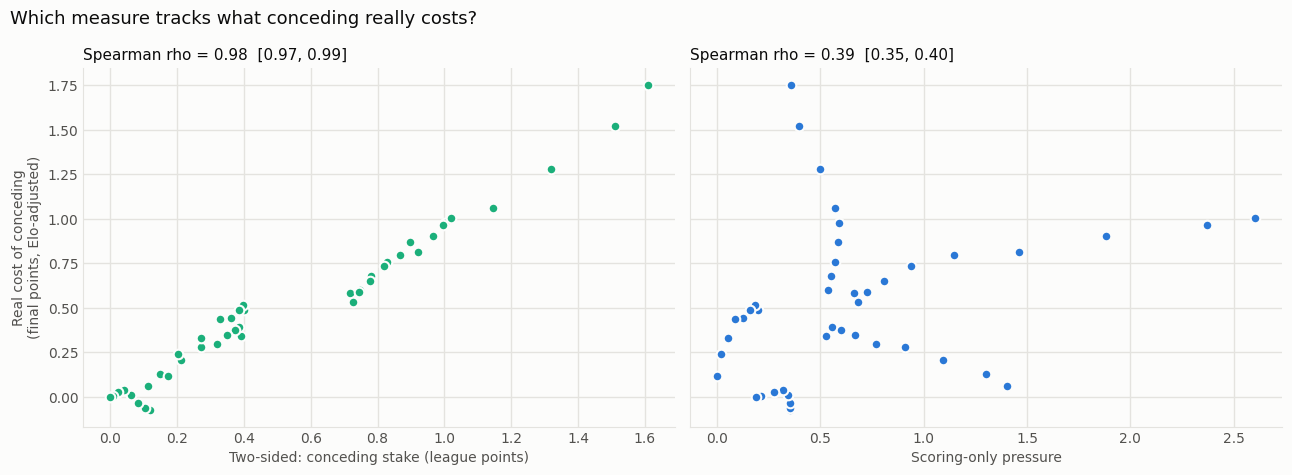

Saved: ../stage7_validation/plots/validity_real_cost_of_conceding.png


In [7]:
# Each dot is one (10-minute bin, goal difference) cell. One series per panel.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, facecolor=SURFACE)
for ax, col, colour, label, k in [
        (axes[0], 'model_cost',   '#1baf7a', 'Two-sided: conceding stake (league points)', 0),
        (axes[1], 'scoring_only', '#2a78d6', 'Scoring-only pressure',                      1)]:
    ax.scatter(cells_obs[col], cells_obs['real_cost'], s=48, color=colour,
               edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.set_title(f'Spearman rho = {t2_obs[k]:.2f}  [{t2_table.iloc[k, 1]:.2f}, {t2_table.iloc[k, 2]:.2f}]',
                 loc='left', fontsize=11, color=INK)
    ax.set_xlabel(label, color=INK_2)
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, lw=1, ls='-')
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)
axes[0].set_ylabel('Real cost of conceding\n(final points, Elo-adjusted)', color=INK_2)
fig.suptitle('Which measure tracks what conceding really costs?', x=0.01, ha='left', fontsize=13, color=INK)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'validity_real_cost_of_conceding.png', dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"Saved: {PLOTS_DIR / 'validity_real_cost_of_conceding.png'}")

In [8]:
g_idx = df['game_id'].map(GAME_IX).values
assert not np.isnan(g_idx).any(), 'every action must belong to a match with a final result'
g_idx = g_idx.astype(int)
sums = lambda mask, w: np.bincount(g_idx[mask], weights=w[mask], minlength=N_GAMES)

lead_late_a = ((df['goal_difference'] == 1) & (df['minute'] >= 80)).values
ahead_a     = (df['goal_difference'] >= 1).values
num = {'weight on stopping a goal, leading by 1 (80\'+)': (sums(lead_late_a, w_minus.values),
                                                          sums(lead_late_a, w_scoring.values))}
for pos in ['goalkeeper', 'defender', 'midfielder']:
    m_ = ahead_a & (df['position_group'] == pos).values
    num[f'goal-prevention credit while ahead, {pos}s'] = (sums(m_, (defend * w_minus).values),
                                                          sums(m_, (defend * w_scoring).values))
t3 = lambda wg: {k: (wg @ a) / (wg @ b) for k, (a, b) in num.items()}
t3_obs  = t3(np.ones(N_GAMES))
t3_boot = pd.DataFrame([t3(draw()) for _ in range(1000)])
t3_table = pd.DataFrame({'two-sided / scoring-only': pd.Series(t3_obs),
                         'ci_low': t3_boot.quantile(0.025), 'ci_high': t3_boot.quantile(0.975),
                         'p (ratio <= 1)': (t3_boot <= 1).mean()})
print('T3. Credit ratios, two-sided / scoring-only, with 95% bootstrap intervals over matches')
print(t3_table.round(3).to_string())
t3_table.to_csv(OUT_DIR / 't3_credit_ratios.csv')

T3. Credit ratios, two-sided / scoring-only, with 95% bootstrap intervals over matches
                                                 two-sided / scoring-only  ci_low  ci_high  p (ratio <= 1)
weight on stopping a goal, leading by 1 (80'+)                      4.610   4.562    4.658             0.0
goal-prevention credit while ahead, goalkeepers                     2.569   2.507    2.647             0.0
goal-prevention credit while ahead, defenders                       2.745   2.607    2.894             0.0
goal-prevention credit while ahead, midfielders                     3.007   2.686    3.513             0.0


In [9]:
lead = t1_table.loc['leading by 1']
print('SUMMARY')
print('=' * 96)
print(f"T1  Real results, leading by 1 at 80'+: conceding cost {lead['real_cost']:.2f} pts, scoring gained "
      f"{lead['real_gain']:.2f} pts; difference {lead['cost_minus_gain']:+.2f} "
      f"[{lead['ci_low']:+.2f}, {lead['ci_high']:+.2f}], p = {lead['p_value']:.3f}")
for label, (est, lo, hi, p) in t2_diffs.items():
    print(f"T2  {label}: {est:+.2f} [{lo:+.2f}, {hi:+.2f}], p = {p:.3f}")
for k, r in t3_table.iterrows():
    print(f"T3  {k}: x{r['two-sided / scoring-only']:.2f} [{r['ci_low']:.2f}, {r['ci_high']:.2f}]")

SUMMARY
T1  Real results, leading by 1 at 80'+: conceding cost 1.59 pts, scoring gained 0.20 pts; difference +1.40 [+1.30, +1.48], p = 0.000
T2  conceding side: two-sided minus scoring-only: +0.59 [+0.58, +0.62], p = 0.000
T2  total stakes:   two-sided minus scoring-only: +0.22 [+0.19, +0.25], p = 0.000
T3  weight on stopping a goal, leading by 1 (80'+): x4.61 [4.56, 4.66]
T3  goal-prevention credit while ahead, goalkeepers: x2.57 [2.51, 2.65]
T3  goal-prevention credit while ahead, defenders: x2.74 [2.61, 2.89]
T3  goal-prevention credit while ahead, midfielders: x3.01 [2.69, 3.51]
